In [2]:
pip install pytrends

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

# Suppose you are working in a data-driven job role, and you have to answer all these questions.

### 1.First, write a code where, by changing just the keyword, we can search for multiple things.

### 2.Top 15 countries where the keywords are searched the most, and also create visual representation.

### 3.A world map needs to be plotted showing the countries that search the keyword the most.

### 4.We need to extract the time-wise interest of the keyword — how it trended in different years.

### 5.Compare related keywords and plot the graph.

# set up pytrend library and keyword define

In [7]:
pytrends= TrendReq(hl = 'en-us',tz=360)
keyword="cloud computing"

# data request

In [8]:
pytrends.build_payload([keyword],cat=0,timeframe='today 12-m',geo='',gprop='')

# country wise interest 

In [11]:
region_data=pytrends.interest_by_region()
region_data= region_data.sort_values(by=keyword,ascending=False).head(15)

C:\Users\deepa\AppData\Local\Temp\ipykernel_18580\3625955609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_data[keyword],y=region_data.index,palette="Blues_d")


<function matplotlib.pyplot.show(close=None, block=None)>

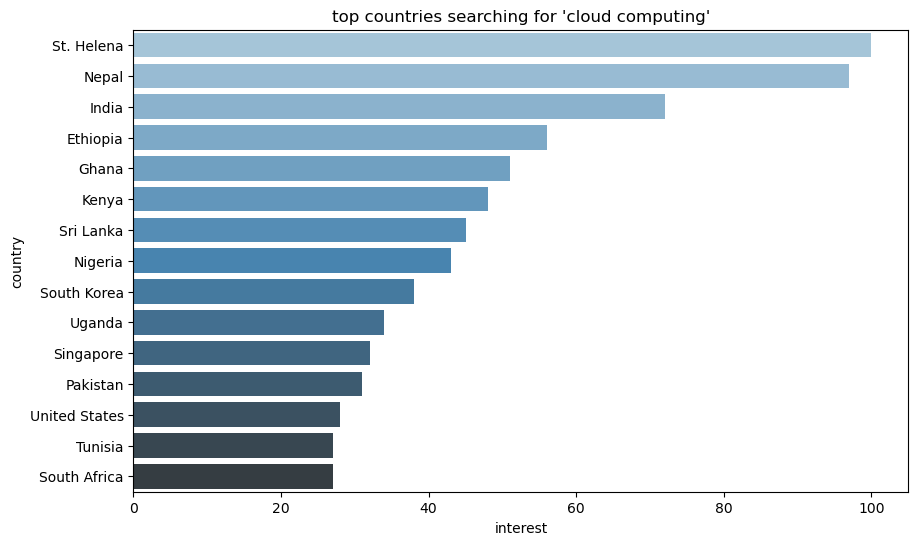

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette="Blues_d")
plt.title(f"top countries searching for '{keyword}'")
plt.xlabel("interest")
plt.ylabel("country")
plt.show

# world map

C:\Users\deepa\AppData\Local\Temp\ipykernel_18580\2715713854.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



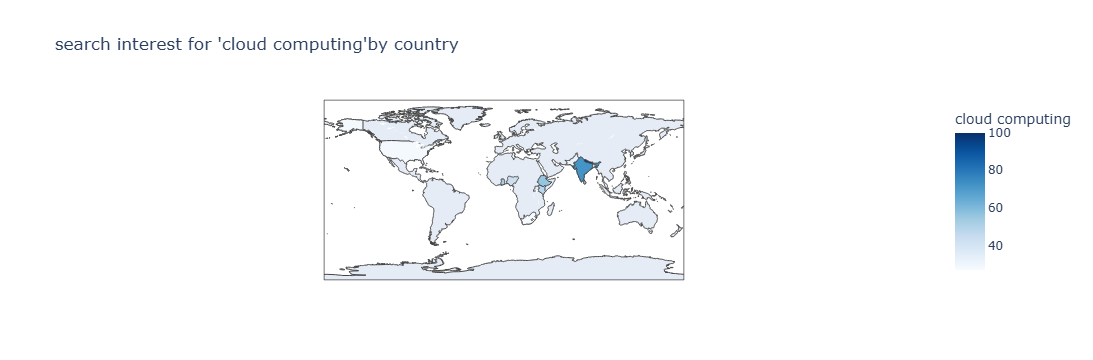

In [17]:
region_data = region_data.reset_index()
fig= px.choropleth(region_data,
                  locations = 'geoName',
                  locationmode='country names',
                  color = keyword,
                  title = f"search interest for '{keyword}'by country",
                  color_continuous_scale='blues')
fig.show()

# time wise interest 

In [18]:
time_df=pytrends.interest_over_time()

C:\Users\deepa\Downloads\anaconda\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



<function matplotlib.pyplot.show(close=None, block=None)>

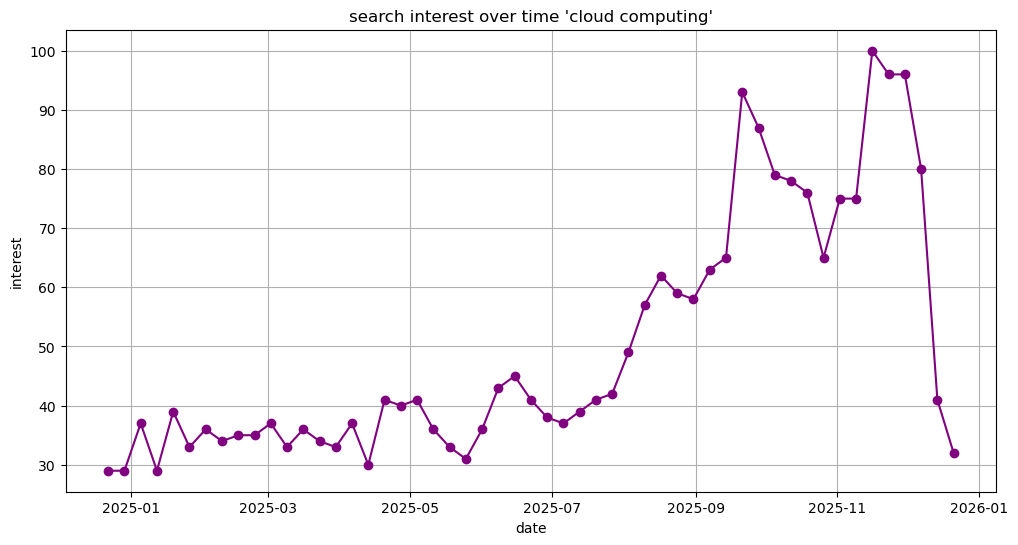

In [22]:
plt.figure (figsize=(12,6))
plt.plot(time_df.index,time_df[keyword],marker='o' ,color ='purple')
plt.title(f"search interest over time '{keyword}'")
plt.xlabel("date")
plt.ylabel("interest")
plt.grid(True)
plt.show

# multiple keywords compare

In [23]:
kw_list=["cloud computing","data science","machine learning"]
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

C:\Users\deepa\Downloads\anaconda\Lib\site-packages\pytrends\request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



<function matplotlib.pyplot.show(close=None, block=None)>

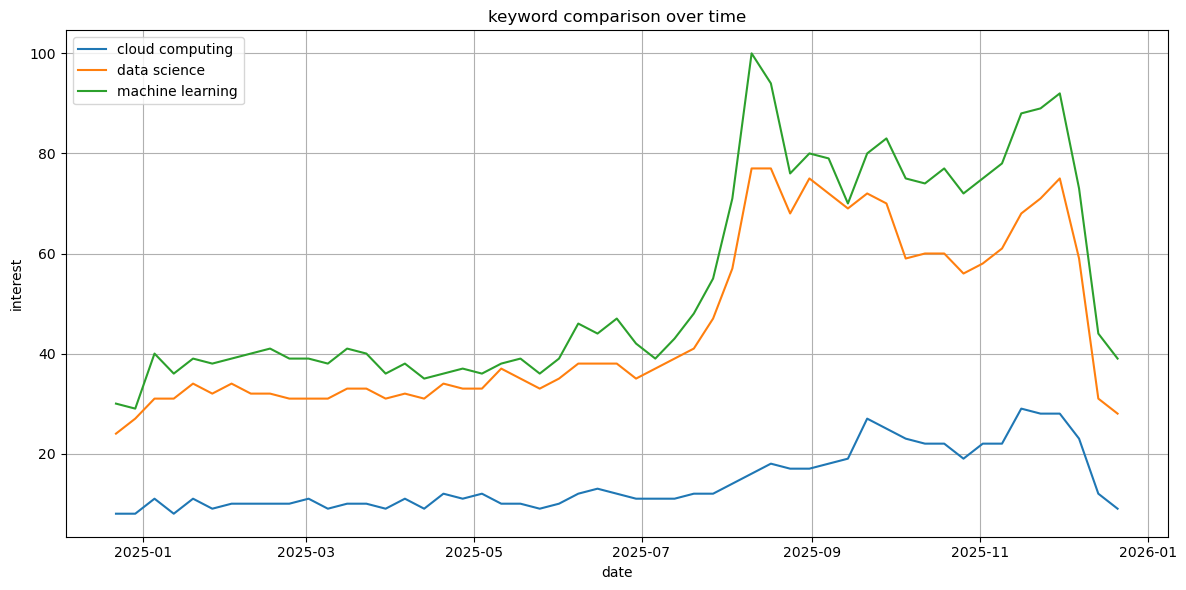

In [27]:
compare_df=pytrends.interest_over_time()
plt.figure(figsize=(12,6))
for kw in kw_list:
    plt.plot(compare_df.index,compare_df[kw],label=kw)

    
plt.title("keyword comparison over time")    
plt.xlabel("date")
plt.ylabel("interest")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show

